<a href="https://colab.research.google.com/github/Spoorthy2001/ml_as_beginner/blob/development/projects/machine_failure_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement 1 — Kaggle dataset
Given a snapshot of sensor readings from an industrial machine at a single point in time — including temperature, rotational speed, torque, and tool wear — predict whether the machine will fail, and if so, classify the type of failure from five known failure modes: heat dissipation, power failure, overstrain, tool wear, or random failure.

1. **Type**: Multiclass classification
2. **Target**: Failure Type
3. **Challenge**: Severe class imbalance — 96.5% of rows are No Failure

# Feature Engineering

1. **Visualize data**
2. **Handle Missing values**
3. **Outliers**
4. **Scaling data**

In [ ]:
import kagglehub
path = kagglehub.dataset_download("shivamb/machine-predictive-maintenance-classification")

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_machine_failure_data = pd.read_csv(path + '/predictive_maintenance.csv')
df_machine_failure_data.head()

Using Colab cache for faster access to the 'machine-predictive-maintenance-classification' dataset.


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [ ]:
# df_machine_failure_data.describe()
df_machine_failure_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


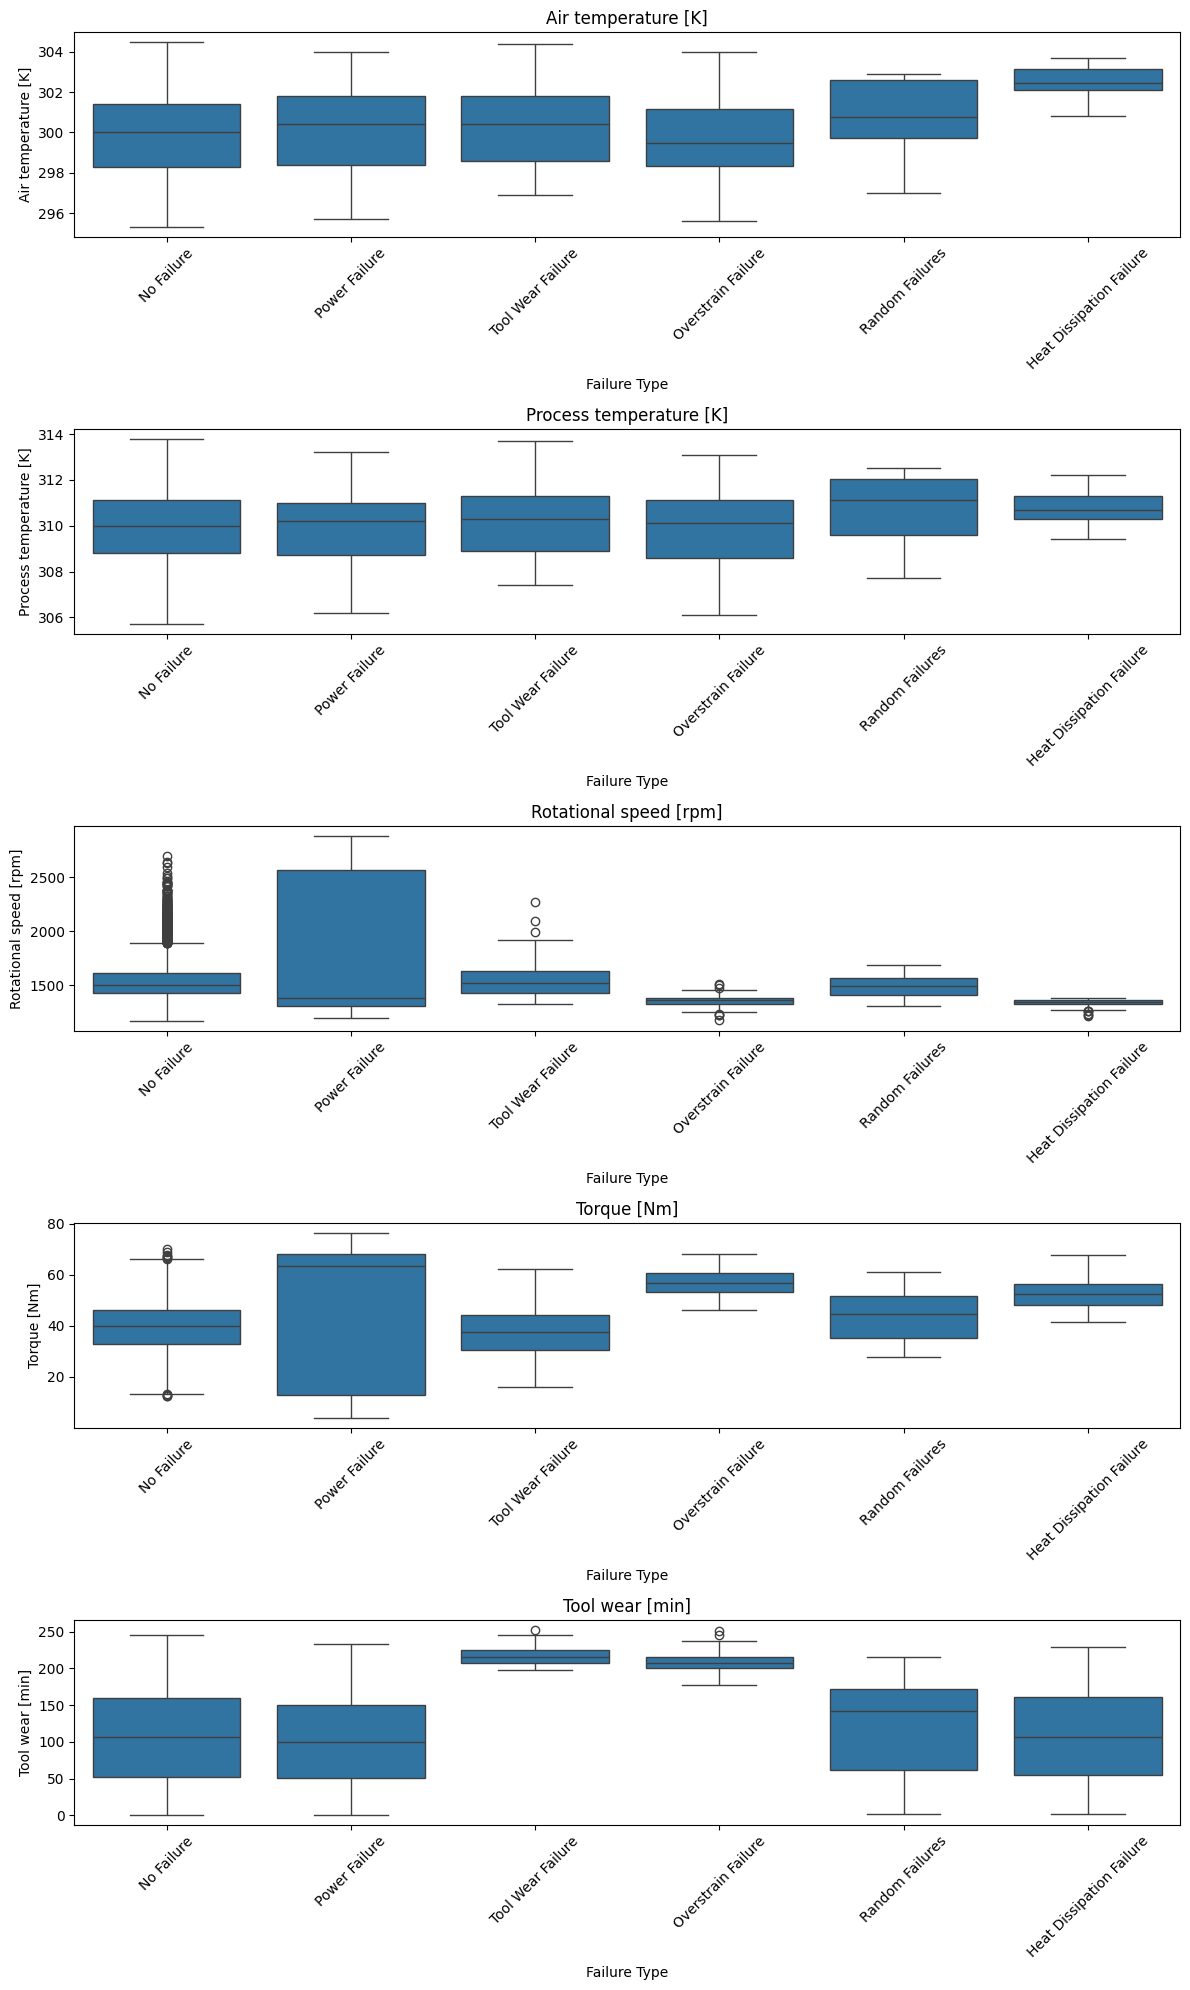

In [ ]:
features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

figs, axes = plt.subplots(len(features), 1, figsize=(12, 20))

for i, feature in enumerate(features):
    sns.boxplot(data=df_machine_failure_data, x='Failure Type', y=feature, ax=axes[i])
    axes[i].set_title(feature)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()